In [1]:
import pandas as pd

In [2]:
dataset=pd.read_csv("DillibabuSarva_DefectDataset.csv")

In [3]:
dataset.isnull().sum()

SHA                     0
cbo                     0
wmc                     0
dit                     0
rfc                     0
lcom                    0
totalMethods            0
totalFields             0
nosi                    0
loc                     0
returnQty               0
loopQty                 0
comparisonsQty          0
tryCatchQty             0
parenthesizedExpsQty    0
stringLiteralsQty       0
numbersQty              0
assignmentsQty          0
mathOperationsQty       0
variablesQty            0
maxNestedBlocks         0
uniqueWordsQty          0
defect                  0
dtype: int64

In [4]:
import seaborn as sns

In [5]:
#!pip install seaborn

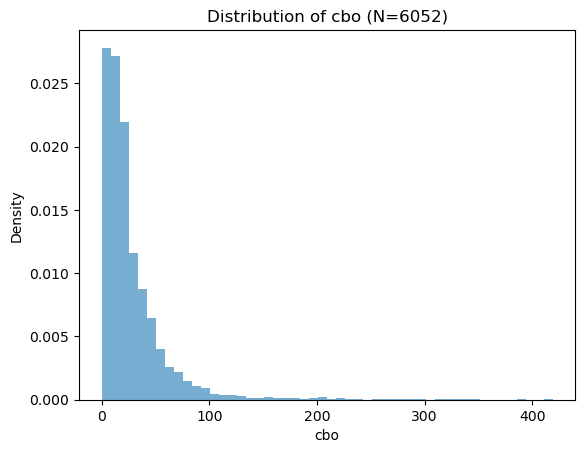

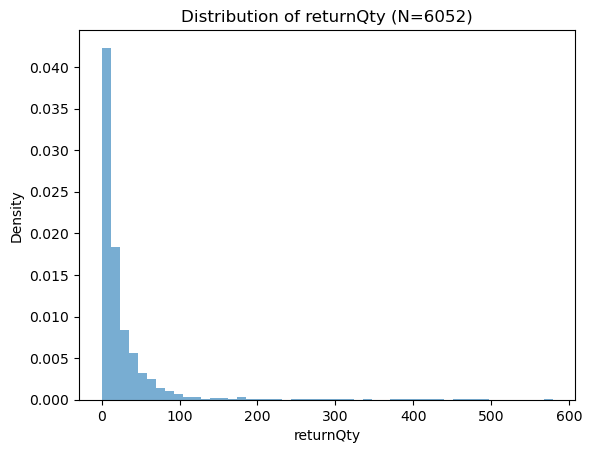

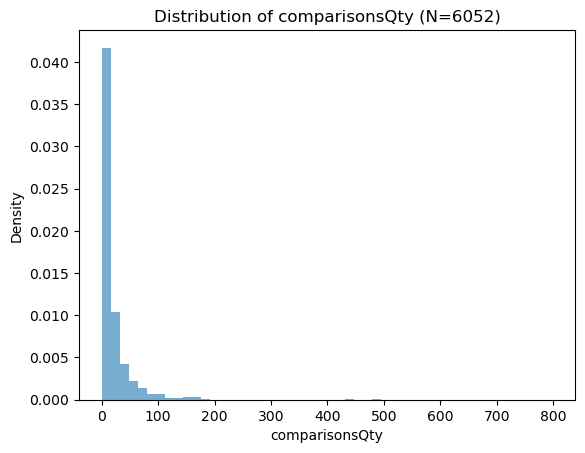

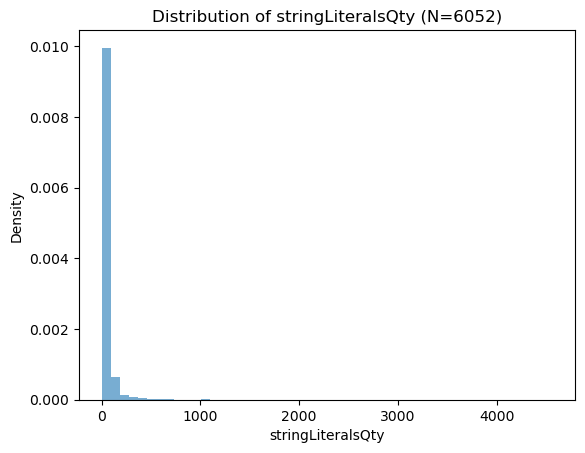

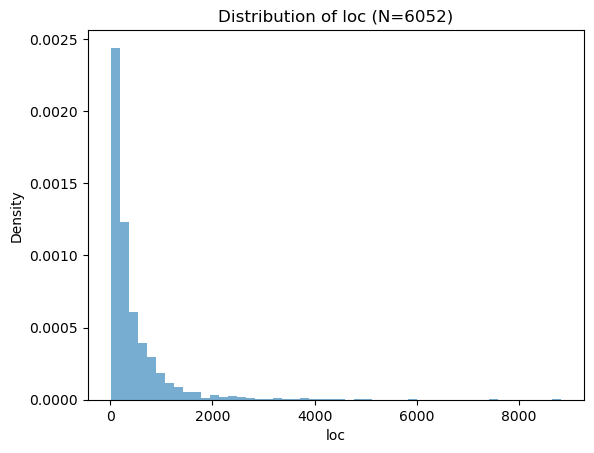

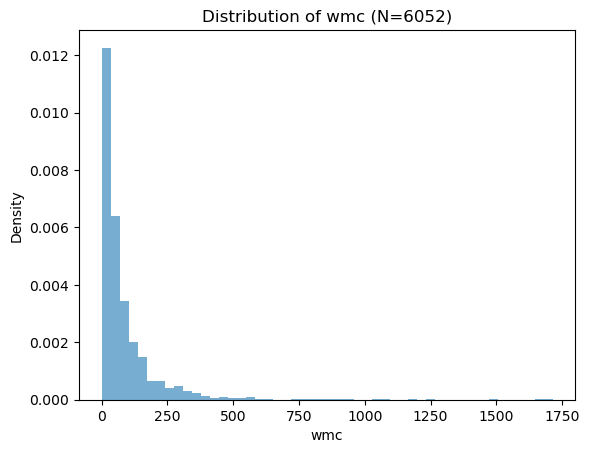

In [6]:
import matplotlib.pyplot as plt
# BEST columns for distplot in your dataset:
cols_for_distplot = ['cbo', 'returnQty', 'comparisonsQty', 'stringLiteralsQty', 'loc', 'wmc']

# 1. Simple distplot (histogram + KDE)
for col in cols_for_distplot:
    plt.figure()
    plt.hist(dataset[col], bins=50, density=True, alpha=0.6)
    plt.title(f'Distribution of {col} (N=6052)')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.savefig(f'dist_{col}.png', dpi=200)

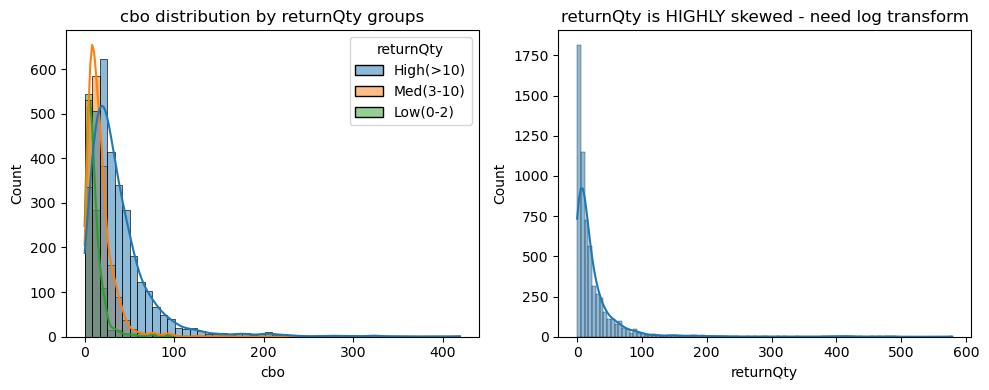

In [10]:
# This is the most important plot for our ANOVA
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(data=dataset, x='cbo', hue=dataset['returnQty'].apply(lambda x: 'Low(0-2)' if x<=2 else 'Med(3-10)' if x<=10 else 'High(>10)'),
             kde=True, bins=50)
plt.title('cbo distribution by returnQty groups')

plt.subplot(1,2,2)
sns.histplot(data=dataset, x='returnQty', bins=100, kde=True)
plt.title('returnQty is HIGHLY skewed - need log transform')
plt.tight_layout()

In [ ]:
# From above, we can see the best column as 'cbo' for distplot - Continuous, shows coupling distribution

Text(0.5, 1.0, 'cbo distribution by defect - for t-test assumption')

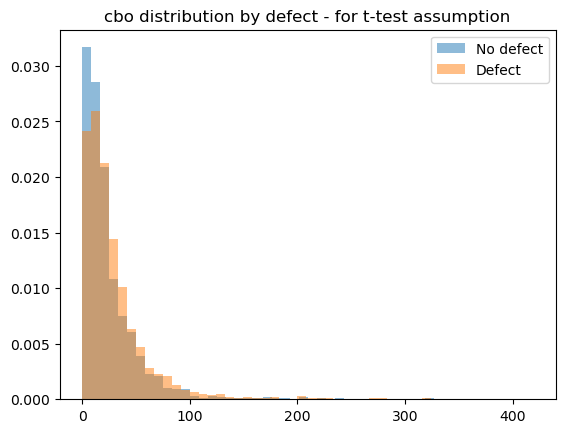

In [11]:
# Distplot of cbo for defect=0 vs defect=1 (for t-test)
plt.figure()
plt.hist(dataset[dataset['defect']==0]['cbo'], bins=50, alpha=0.5, label='No defect', density=True)
plt.hist(dataset[dataset['defect']==1]['cbo'], bins=50, alpha=0.5, label='Defect', density=True)
plt.legend()
plt.title('cbo distribution by defect - for t-test assumption')

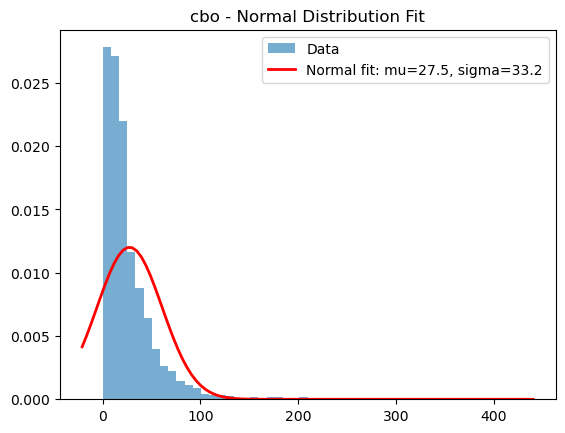

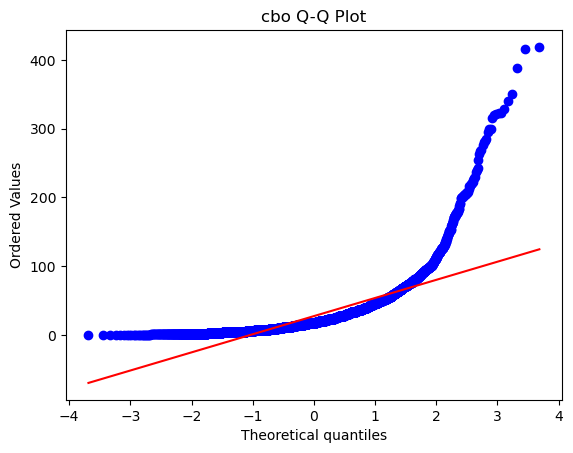

cbo: W=0.6159, p=2.1280e-42 -> NOT NORMAL


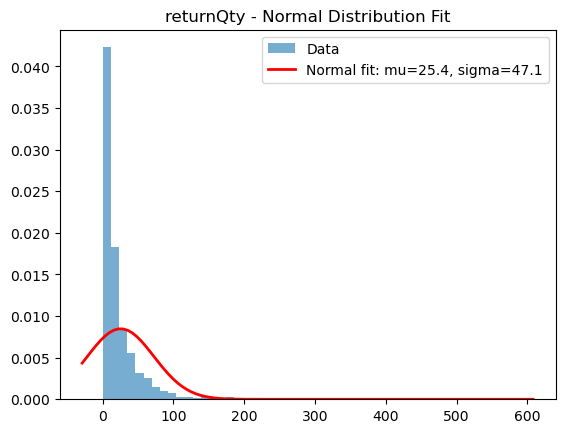

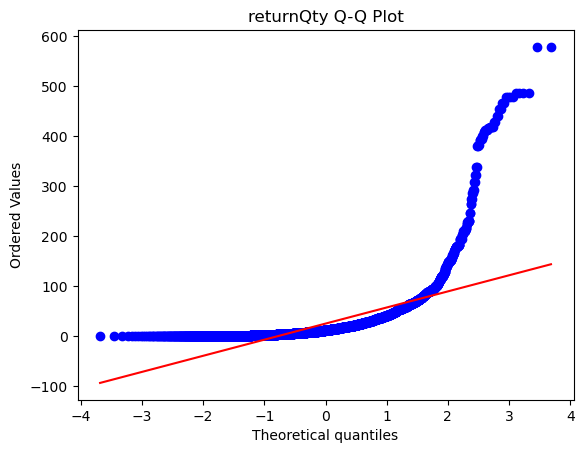

returnQty: W=0.4971, p=1.8615e-46 -> NOT NORMAL


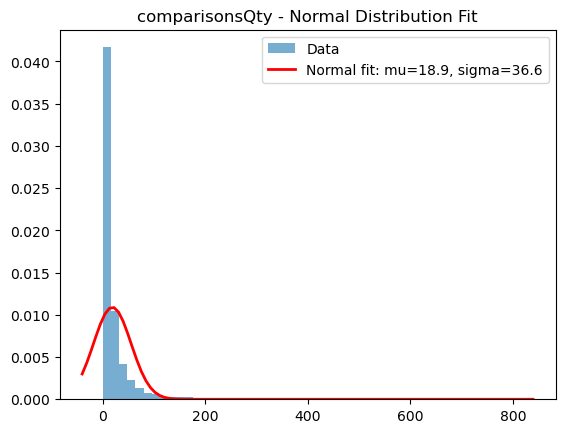

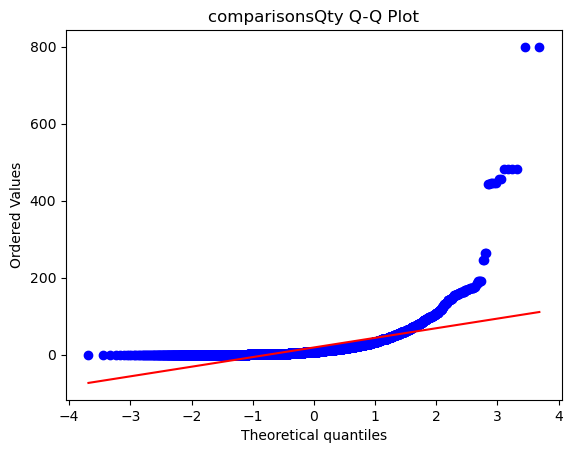

comparisonsQty: W=0.5240, p=1.3027e-45 -> NOT NORMAL


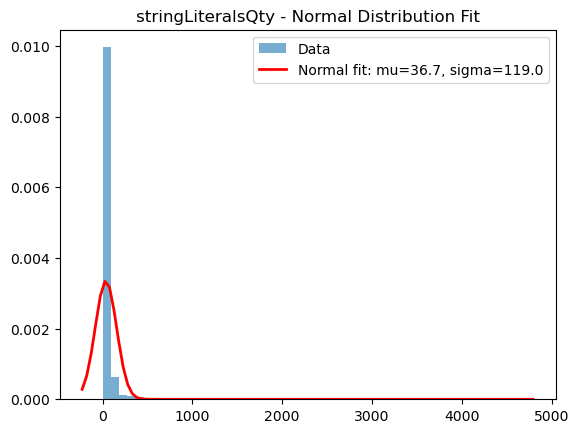

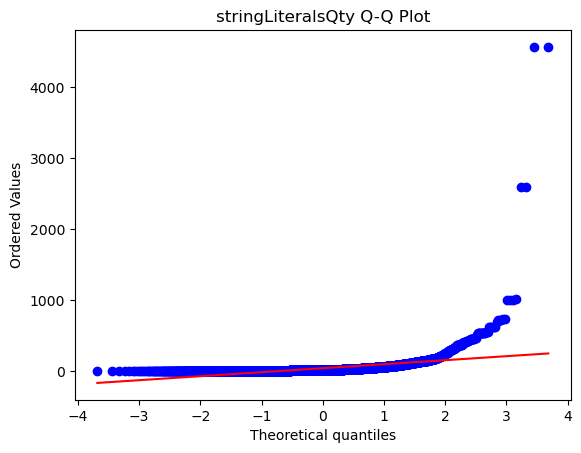

stringLiteralsQty: W=0.4273, p=1.7572e-48 -> NOT NORMAL


In [14]:
import numpy as np
from scipy.stats import norm, probplot, shapiro
cols = ['cbo','returnQty','comparisonsQty','stringLiteralsQty']

for col in cols:
    data = dataset[col]

    # Fit normal distribution
    mu, std = norm.fit(data)

    # Plot histogram + fitted normal curve
    plt.hist(data, bins=50, density=True, alpha=0.6, label='Data')
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, std)
    plt.plot(x, p, 'r', linewidth=2, label=f'Normal fit: mu={mu:.1f}, sigma={std:.1f}')
    plt.title(f'{col} - Normal Distribution Fit')
    plt.legend()
    plt.show()

    # Q-Q Plot (best for normality check)
    probplot(data, dist="norm", plot=plt)
    plt.title(f'{col} Q-Q Plot')
    plt.show()

    # Shapiro-Wilk test
    sample = dataset[col].sample(1000) # Shapiro needs <5000
    stat, p = shapiro(sample)
    print(f"{col}: W={stat:.4f}, p={p:.4e} -> {'NOT NORMAL' if p<0.05 else 'NORMAL'}")

Text(0.5, 1.0, 'log1p(cbo) - Now much more Normal!')

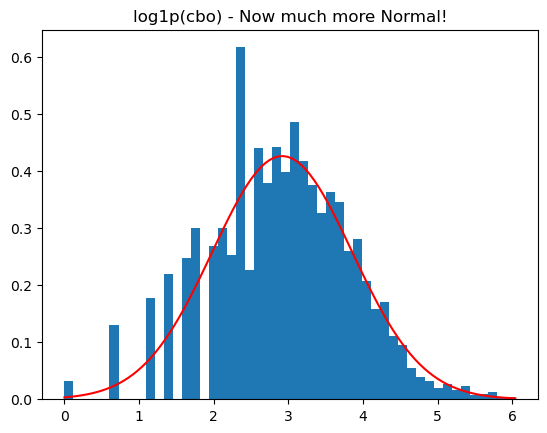

In [17]:
# For our ANOVA/t-test, use log transformation
dataset['log_cbo'] = np.log1p(dataset['cbo'])
dataset['log_returnQty'] = np.log1p(dataset['returnQty'])

# Now check - much more normal
plt.hist(dataset['log_cbo'], bins=50, density=True)
mu, std = norm.fit(dataset['log_cbo'])
x = np.linspace(dataset['log_cbo'].min(), dataset['log_cbo'].max(), 100)
plt.plot(x, norm.pdf(x, mu, std), 'r')
plt.title('log1p(cbo) - Now much more Normal!')